# Historial + género + una feature suya

A partir del ejemplo historial + genre de clase:

    e_i = embed(id) + W_g * g_i
    e_u = mean(e_i del historial)
    score = (e_u * e_i)

Se les solicita: **una característica más al embedding del usuario**. 

En `u.user` hay edad, género y ocupación.

Cómo incluirla queda a su creatividad: un Linear, concatenar y proyectar, one-hot, un flag. Lo que no va a funcionar bien es pasarle directamente edad: "43" a una capa.


In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)



device: cuda


In [12]:
def load_ml100k(min_rating=4):
    ratings = pd.read_csv("./data/ml-100k/u.data", sep="\t",
                          names=["user_raw", "item_raw", "rating", "ts"])
    movies = pd.read_csv("./data/ml-100k/u.item", sep="|",
                         encoding="latin-1", header=None)
    movies = movies.rename(columns={0: "item_raw", 1: "title", 2: "released"})
    genre_cols = list(range(5, 24))
    pos = ratings[ratings.rating >= min_rating].copy()

    user_ids = {u: i for i, u in enumerate(sorted(pos.user_raw.unique()))}
    item_ids = {m: i for i, m in enumerate(sorted(pos.item_raw.unique()))}
    pos["u"] = pos.user_raw.map(user_ids)
    pos["i"] = pos.item_raw.map(item_ids)

    titles, years = {}, {}
    genres = np.zeros((len(item_ids), len(genre_cols)), dtype=np.float32)
    for r in movies.itertuples(index=False):
        raw = r[0]
        if raw not in item_ids:
            continue
        j = item_ids[raw]
        titles[j] = r[1]
        genres[j] = np.array([r[c] for c in genre_cols], dtype=np.float32)
        date = str(r[2]) if r[2] is not None else ""
        yr = None
        if len(date) >= 4 and date[-4:].isdigit():
            yr = int(date[-4:])
        years[j] = yr

    known = [y for y in years.values() if y is not None]
    med = int(np.median(known)) if known else 1995
    year_vec = np.array(
        [years[i] if years[i] is not None else med for i in range(len(item_ids))],
        dtype=np.float32,
    )
    return pos, titles, genres, year_vec, len(user_ids), len(item_ids)

GENRE_NAMES = []
with open("./data/ml-100k/u.genre", "r", encoding="latin-1") as f:
    for line in f:
        name = line.split("|")[0].strip()
        if name:
            GENRE_NAMES.append(name)

pos, TITLES, GENRES, YEARS, N_USERS, N_ITEMS = load_ml100k()
print(len(pos), "positivos |", N_USERS, "users |", N_ITEMS, "items")
print("años", int(YEARS.min()), "->", int(YEARS.max()), "mediana", int(np.median(YEARS)))
print(GENRE_NAMES)



55375 positivos | 942 users | 1447 items
años 1922 -> 1998 mediana 1995
['unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [13]:
def leave_one_last(df):
    df = df.sort_values(["u", "ts"])
    test_rows, train_parts = [], []
    for u, g in df.groupby("u", sort=False):
        if len(g) < 2:
            train_parts.append(g)
            continue
        test_rows.append(g.iloc[-1])
        train_parts.append(g.iloc[:-1])
    return pd.concat(train_parts, ignore_index=True), pd.DataFrame(test_rows)

train_df, test_df = leave_one_last(pos)
print(f"train={len(train_df)} test={len(test_df)}")

HIST = {}
for u, i in zip(train_df.u.to_numpy(), train_df.i.to_numpy()):
    HIST.setdefault(int(u), []).append(int(i))
TEST = {int(u): int(i) for u, i in zip(test_df.u.to_numpy(), test_df.i.to_numpy())}
SEEN = {u: set(items) for u, items in HIST.items()}

pop_count = train_df.i.value_counts()
POP_RANK = pop_count.index.to_numpy()



train=54433 test=942


Popularidad, Hit@10 y NDCG


In [14]:
def hit_ndcg(ranked, truth, k=10):
    if truth in ranked[:k]:
        rank = ranked.index(truth) + 1
        return 1.0, 1.0 / np.log2(rank + 1)
    return 0.0, 0.0

def eval_model(rec_fn, k=10):
    hits, ndcgs = [], []
    for u, truth in TEST.items():
        rec = rec_fn(u, SEEN.get(u, set()), k)
        h, n = hit_ndcg(rec, truth, k)
        hits.append(h); ndcgs.append(n)
    return float(np.mean(hits)), float(np.mean(ndcgs))

def eval_popularity(k=10):
    def rec(u, seen, k):
        return [int(i) for i in POP_RANK if i not in seen][:k]
    return eval_model(rec, k)

h_pop, n_pop = eval_popularity(10)
print(f"Popularidad  Hit@10={h_pop:.3f}  NDCG@10={n_pop:.3f}")



Popularidad  Hit@10=0.079  NDCG@10=0.040


Mean + género visto en clase. Usar el hit y ndcg como baseline


In [15]:
DIM, N_NEG, MAX_HIST = 32, 4, 20

class HistDS(Dataset):
    def __init__(self, df, hist, n_items, max_len=MAX_HIST, n_neg=N_NEG):
        self.users = df.u.to_numpy().astype(np.int64)
        self.items = df.i.to_numpy().astype(np.int64)
        self.hist, self.n_items, self.max_len, self.n_neg = hist, n_items, max_len, n_neg

    def _pack(self, u, drop_item=None):
        h = [x for x in self.hist[int(u)] if x != drop_item][-self.max_len:]
        pad = self.max_len - len(h)
        return (np.array([self.n_items]*pad + h, np.int64),
                np.array([0.0]*pad + [1.0]*len(h), np.float32))

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u, pos = int(self.users[idx]), int(self.items[idx])
        seq, mask = self._pack(u, drop_item=pos)
        negs, seen = [], SEEN.get(u, set())
        while len(negs) < self.n_neg:
            j = np.random.randint(0, self.n_items)
            if j != pos and j not in seen:
                negs.append(j)
        return seq, mask, np.array([pos, *negs], np.int64), np.array([1.0]+[0.0]*self.n_neg, np.float32)


class MeanTowerGenre(nn.Module):
    def __init__(self, n_items, genres, dim=DIM):
        super().__init__()
        self.item = nn.Embedding(n_items + 1, dim, padding_idx=n_items)
        self.genre = nn.Linear(genres.shape[1], dim, bias=False)
        self.register_buffer("G", torch.tensor(genres))
        nn.init.normal_(self.item.weight[:-1], std=0.1)

    def item_vec(self, items):
        flat = items.reshape(-1)
        g = torch.zeros(flat.size(0), self.G.size(1), device=items.device)
        valid = flat < self.G.size(0)
        g[valid] = self.G[flat[valid]]
        return self.item(items) + self.genre(g).reshape(*items.shape, -1)

    def encode_user(self, seq, mask):
        e = self.item_vec(seq)
        m = mask.unsqueeze(-1)
        return F.normalize((e * m).sum(1) / m.sum(1).clamp(min=1), dim=-1)

    def score(self, seq, mask, items):
        eu = self.encode_user(seq, mask)
        ei = F.normalize(self.item_vec(items), dim=-1)
        return (eu * ei).sum(-1) if ei.dim() == 2 else (eu.unsqueeze(1) * ei).sum(-1)


def train_hist(model, loader, epochs=6, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for ep in range(1, epochs + 1):
        total = n = 0
        for seq, mask, targets, labels in loader:
            B, C = targets.shape
            seq, mask = seq.to(DEVICE), mask.to(DEVICE)
            targets, labels = targets.to(DEVICE), labels.to(DEVICE)
            seq_rep = seq.unsqueeze(1).expand(B, C, seq.size(1)).reshape(B * C, -1)
            mask_rep = mask.unsqueeze(1).expand(B, C, mask.size(1)).reshape(B * C, -1)
            loss = F.binary_cross_entropy_with_logits(
                model.score(seq_rep, mask_rep, targets.reshape(-1)) * 8,
                labels.reshape(-1),
            )
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item() * B * C; n += B * C
        print(f"  epoch {ep}/{epochs}  loss={total/n:.4f}")

loader_h = DataLoader(HistDS(train_df, HIST, N_ITEMS), batch_size=512, shuffle=True)
base = MeanTowerGenre(N_ITEMS, GENRES).to(DEVICE)
print("baseline: mean + genero")
train_hist(base, loader_h, epochs=6)



baseline: mean + genero
  epoch 1/6  loss=1.1377
  epoch 2/6  loss=0.7206
  epoch 3/6  loss=0.6025
  epoch 4/6  loss=0.5493
  epoch 5/6  loss=0.5168
  epoch 6/6  loss=0.4924


In [16]:
def pack_user(u, max_len=MAX_HIST):
    h = HIST[u][-max_len:]
    pad = max_len - len(h)
    return (torch.tensor([[N_ITEMS]*pad + h], device=DEVICE),
            torch.tensor([[0.0]*pad + [1.0]*len(h)], device=DEVICE))

@torch.no_grad()
def recommend(model, user_id, seen, k=10):
    model.eval()
    seq, mask = pack_user(user_id)
    eu = model.encode_user(seq, mask)
    ei = F.normalize(model.item_vec(torch.arange(N_ITEMS, device=DEVICE)), dim=-1)
    scores = (eu @ ei.T).squeeze(0).cpu().numpy()
    scores[list(seen)] = -1e9
    top = np.argpartition(-scores, k)[:k]
    return top[np.argsort(-scores[top])].tolist()

h0, n0 = eval_model(lambda u,s,k: recommend(base, u, s, k))
print(f"mean+genero  Hit@10={h0:.3f}  NDCG@10={n0:.3f}")



mean+genero  Hit@10=0.086  NDCG@10=0.039


Aqui hay un ejemplo de como añadir el año (normalizado a 0–1) al ítem.

In [17]:
Y_NORM = ((YEARS - YEARS.min()) / (YEARS.max() - YEARS.min() + 1e-8)).reshape(-1, 1)

class MeanGenreYear(nn.Module):
    def __init__(self, n_items, genres, years_norm, dim=DIM):
        super().__init__()
        self.item = nn.Embedding(n_items + 1, dim, padding_idx=n_items)
        self.genre = nn.Linear(genres.shape[1], dim, bias=False)
        self.year = nn.Linear(1, dim, bias=False)
        self.register_buffer("G", torch.tensor(genres))
        self.register_buffer("Y", torch.tensor(years_norm))
        nn.init.normal_(self.item.weight[:-1], std=0.1)

    def item_vec(self, items):
        n_items = self.G.size(0)
        flat = items.reshape(-1)
        g = torch.zeros(flat.size(0), self.G.size(1), device=items.device)
        y = torch.zeros(flat.size(0), 1, device=items.device)
        valid = flat < n_items
        g[valid] = self.G[flat[valid]]
        y[valid] = self.Y[flat[valid]]
        e_id = self.item(items)
        e_g = self.genre(g).reshape(*items.shape, -1)
        e_y = self.year(y).reshape(*items.shape, -1)
        return e_id + e_g + e_y

    def encode_user(self, seq, mask):
        e = self.item_vec(seq)
        m = mask.unsqueeze(-1)
        return F.normalize((e * m).sum(1) / m.sum(1).clamp(min=1), dim=-1)

    def score(self, seq, mask, items):
        eu = self.encode_user(seq, mask)
        ei = F.normalize(self.item_vec(items), dim=-1)
        return (eu * ei).sum(-1) if ei.dim() == 2 else (eu.unsqueeze(1) * ei).sum(-1)

model = MeanGenreYear(N_ITEMS, GENRES, Y_NORM).to(DEVICE)
print("mean + genero + anio")
train_hist(model, loader_h, epochs=6)

h1, n1 = eval_model(lambda u,s,k: recommend(model, u, s, k))
print(f"mean+genero+anio Hit@10={h1:.3f}  NDCG@10={n1:.3f}")
print(f"baseline mean+genero Hit@10={h0:.3f}  NDCG@10={n0:.3f}")
print(f"popularidad      Hit@10={h_pop:.3f}  NDCG@10={n_pop:.3f}")



mean + genero + anio
  epoch 1/6  loss=4.8063
  epoch 2/6  loss=1.4015
  epoch 3/6  loss=0.8795
  epoch 4/6  loss=0.7356
  epoch 5/6  loss=0.6573
  epoch 6/6  loss=0.6088
mean+genero+anio Hit@10=0.070  NDCG@10=0.033
baseline mean+genero Hit@10=0.086  NDCG@10=0.039
popularidad      Hit@10=0.079  NDCG@10=0.040


In [18]:
@torch.no_grad()
def neighbors(model, title_substr, k=8):
    E = F.normalize(model.item_vec(torch.arange(N_ITEMS, device=DEVICE)), dim=-1).cpu().numpy()
    hits = [(i, t) for i, t in TITLES.items() if title_substr.lower() in t.lower()]
    if not hits:
        print("no encontrado:", title_substr); return
    i0, t0 = hits[0]
    sim = E @ E[i0]
    gs = [GENRE_NAMES[k] for k,v in enumerate(GENRES[i0]) if v == 1]
    print(f"{t0}  anio={int(YEARS[i0])}  {gs}")
    for j in np.argsort(-sim)[:k+1]:
        gsj = [GENRE_NAMES[k] for k,v in enumerate(GENRES[int(j)]) if v == 1]
        print(f"  {sim[j]:+.3f}  {TITLES.get(int(j))}  ({int(YEARS[int(j)])})  {gsj}")

print("--- baseline (genero) ---")
neighbors(base, "Star Wars")
print()
print("--- + anio ---")
neighbors(model, "Star Wars")
print()



--- baseline (genero) ---
Star Wars (1977)  anio=1977  ['Action', 'Adventure', 'Romance', 'Sci-Fi', 'War']
  +1.000  Star Wars (1977)  (1977)  ['Action', 'Adventure', 'Romance', 'Sci-Fi', 'War']
  +0.832  Return of the Jedi (1983)  (1997)  ['Action', 'Adventure', 'Romance', 'Sci-Fi', 'War']
  +0.707  Empire Strikes Back, The (1980)  (1980)  ['Action', 'Adventure', 'Drama', 'Romance', 'Sci-Fi', 'War']
  +0.704  Star Trek: The Motion Picture (1979)  (1979)  ['Action', 'Adventure', 'Sci-Fi']
  +0.699  Men in Black (1997)  (1997)  ['Action', 'Adventure', 'Comedy', 'Sci-Fi']
  +0.687  Star Trek: First Contact (1996)  (1996)  ['Action', 'Adventure', 'Sci-Fi']
  +0.653  Four Weddings and a Funeral (1994)  (1994)  ['Comedy', 'Romance']
  +0.650  Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)  (1963)  ['Sci-Fi', 'War']
  +0.634  Aliens (1986)  (1986)  ['Action', 'Sci-Fi', 'Thriller', 'War']

--- + anio ---
Star Wars (1977)  anio=1977  ['Action', 'Adventure', 'Romanc

PCA: películas con bastante rating, pocos nombres, color = género


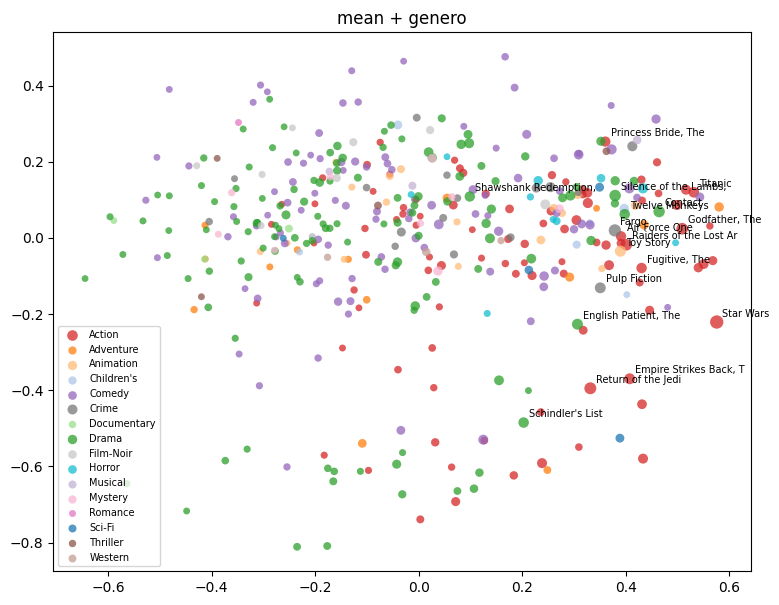

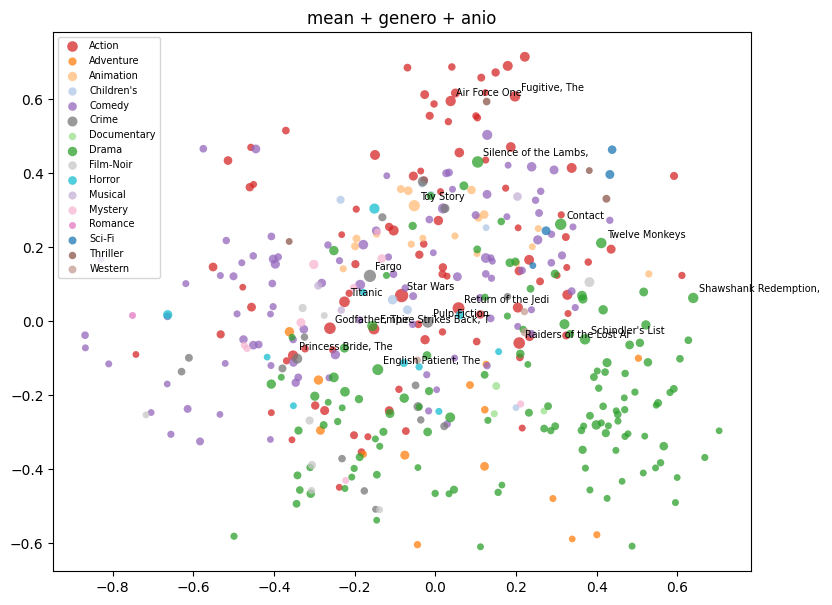

In [19]:
MIN_POP, N_LABELS = 40, 18
COLORS = {
    "unknown":"#ddd","Action":"#d62728","Adventure":"#ff7f0e","Animation":"#ffbb78",
    "Children's":"#aec7e8","Comedy":"#9467bd","Crime":"#777","Documentary":"#98df8a",
    "Drama":"#2ca02c","Fantasy":"#dbdb8d","Film-Noir":"#c7c7c7","Horror":"#17becf",
    "Musical":"#c5b0d5","Mystery":"#f7b6d2","Romance":"#e377c2","Sci-Fi":"#1f77b4",
    "Thriller":"#8c564b","War":"#bcbd22","Western":"#c49c94",
}

def plot_latent(m, title):
    with torch.no_grad():
        E = F.normalize(m.item_vec(torch.arange(N_ITEMS, device=DEVICE)), dim=-1).cpu().numpy()
    pops = np.zeros(N_ITEMS, np.int32)
    for i,c in pop_count.items():
        pops[int(i)] = int(c)
    keep = np.where(pops >= MIN_POP)[0]
    X = E[keep] - E[keep].mean(0)
    _,_,vt = np.linalg.svd(X, full_matrices=False)
    pts = X @ vt[:2].T
    gen = [GENRE_NAMES[int(np.argmax(GENRES[i]))] if GENRES[i].sum() else "unknown" for i in keep]
    fig, ax = plt.subplots(figsize=(9,7))
    for name in sorted(set(gen)):
        idx = [k for k,g in enumerate(gen) if g==name]
        ax.scatter(pts[idx,0], pts[idx,1], s=18+0.15*pops[keep][idx],
                   c=COLORS.get(name,"#333"), alpha=0.75, label=name, linewidths=0)
    for k in np.argsort(-pops[keep])[:N_LABELS]:
        ax.annotate(TITLES.get(int(keep[k]),"").rsplit(" (",1)[0][:22],
                    pts[k], fontsize=7, xytext=(4,4), textcoords="offset points")
    ax.set_title(title); ax.legend(fontsize=7, loc="best"); plt.show()

plot_latent(base, "mean + genero")
plot_latent(model, "mean + genero + anio")



Incluir un resumen de:

Qué le pusieron y cómo
Qué hicieron los "vecinos"

In [20]:
# 
